# Cubist Hackathon
## What We Learned About LLM-Driven Engineering

A prompt-ablation study on antichess engine generation.
We toggled three prompt components — **Architecture**, **Strategy**, **Plan** —
across ten runs and measured *how* the model worked, not just *what* it built.

> **Headline finding:** Strategy is the single highest-leverage prompt component.
> It moves Elo, code quality, and strategic-decision pass rates more than
> Architecture or Planning combined — and at a *fraction* of the token cost.

In [1]:
# ── Imports & presentation styling ──────────────────────────────────────────
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "evaluation" / "results"

# Live-projection styling: large fonts, big figures, sparse decoration.
plt.rcParams.update({
    "font.size":       14,
    "axes.labelsize":  18,
    "axes.titlesize":  22,
    "axes.titleweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize":  (12, 6),
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
PLAN_PALETTE = {False: "#d96459", True:  "#1f9aa0"}  # coral / teal
sns.set_palette([PLAN_PALETTE[False], PLAN_PALETTE[True]])

## 1 · Parse `results.txt` and join with tournaments + correctness

In [2]:
# ── Run_id → engine_name mapping (4 bits: arch | strat | plan | variant) ───
RUN_ID_TO_ENGINE = {
    "0000": "noarch_nostrat_noplan",
    "0010": "noarch_nostrat_yesplan",
    "0100": "noarch_yesstrat_noplan",
    "0110": None,                          # no engine on disk for this run
    "1000": "yesarch_nostrat_noplan",
    "1010": "yesarch-nostrat-yesplan",
    "1100": "yesarch_yessttrat_noplan",
    "1110": "arch1-strat1-plan1",
    "1111": "yesarch_yesstrat_yesplan_p1",
    "1112": "caveman",
}

# Sonnet 4.6 pricing (per million tokens).
PRICE_IN, PRICE_OUT, PRICE_CACHE_R = 3.0, 15.0, 0.30


def parse_token_blob(blob: str) -> dict:
    """Pull (input, output, cached_read, $) from a free-form tokens cell."""
    blob = blob.replace(",", " ").lower()
    nums = re.findall(r"([\d.]+)\s*([km]?)", blob)
    parsed = []
    for raw, suf in nums:
        if not raw or raw == ".":
            continue
        v = float(raw) * (1_000_000 if suf == "m" else 1_000 if suf == "k" else 1)
        parsed.append(v)
    cache_read = next(
        (float(re.match(r"([\d.]+)", m).group(1)) * (1e6 if "m" in m else 1e3 if "k" in m else 1)
         for m in re.findall(r"[\d.]+\s*[km]?\s*cached?\s*read", blob)),
        None,
    )
    dollar = re.search(r"\$([\d.]+)", blob)
    cost = float(dollar.group(1)) if dollar else None
    # Whichever numbers remain after extracting cached_read & $ are input/output.
    leftover = [n for n in parsed if (cache_read is None or abs(n - cache_read) > 0.5)
                                 and (cost is None or abs(n - cost) > 0.5)]
    inp, out = (None, None)
    if "output" in blob and len(leftover) >= 2:
        # "204, 27.1k output" → first is input, second is output
        inp, out = leftover[0], leftover[1]
    elif len(leftover) >= 2:
        inp, out = leftover[0], leftover[1]
    elif len(leftover) == 1:
        out = leftover[0]
    return {"input": inp, "output": out, "cache_read": cache_read, "cost": cost}


def parse_results_txt(text: str) -> pd.DataFrame:
    """`results.txt` is a stride-of-7 vertical layout: run_id, time, tokens, total, code_q, understanding, [eval]."""
    lines = [ln.rstrip() for ln in text.splitlines()]
    # Drop header (first 7 lines) + leading blanks.
    body = lines[7:]
    rows, buf = [], []
    for ln in body:
        if ln.strip() == "":
            if buf:
                rows.append(buf)
                buf = []
        else:
            buf.append(ln.strip())
    if buf:
        rows.append(buf)

    parsed = []
    for r in rows:
        if len(r) < 6:
            continue
        run_id, time_s, tokens_blob, total_blob, cq, und, *rest = r + [""] * (7 - len(r))
        tok = parse_token_blob(tokens_blob)
        total_match = re.match(r"([\d.]+)\s*([km]?)", total_blob.strip().lower())
        total = (float(total_match.group(1)) *
                 (1e6 if total_match.group(2) == "m" else 1e3 if total_match.group(2) == "k" else 1)
                 if total_match else None)
        cq_match  = re.match(r"([\d.]+)", cq)
        und_match = re.match(r"([\d.]+)", und)
        parsed.append({
            "run_id":             run_id,
            "time_s":             float(time_s),
            "input_tokens":       tok["input"],
            "output_tokens":      tok["output"],
            "cached_read_tokens": tok["cache_read"],
            "total_tokens":       total,
            "cost_usd_reported":  tok["cost"],
            "code_quality":       float(cq_match.group(1)) if cq_match else None,
            "understanding":      float(und_match.group(1)) if und_match else None,
        })
    df = pd.DataFrame(parsed)

    df["has_arch"]      = df["run_id"].str[0] == "1"
    df["has_strat"]     = df["run_id"].str[1] == "1"
    df["has_plan"]      = df["run_id"].str[2] == "1"
    df["plan_variant"]  = df["run_id"].str[3].astype(int)
    df["context_level"] = df["has_arch"].astype(int) + df["has_strat"].astype(int)
    df["engine_name"]   = df["run_id"].map(RUN_ID_TO_ENGINE)

    # Two cost columns:
    #   floor = Sonnet 4.6 formula on the tokens we can see (lower bound — most
    #           rows lack cache-write counts, so this consistently undershoots
    #           the reported $).
    #   est   = headline estimate. Where reported $ exists, use it. Where it
    #           doesn't, scale by the median $/token rate observed among rows
    #           that DO have reported $ (this captures cache-write surcharge
    #           empirically without needing every token surface).
    df["cost_usd_floor"] = (
        df["input_tokens"].fillna(0)        * (PRICE_IN       / 1e6)
      + df["output_tokens"].fillna(0)       * (PRICE_OUT      / 1e6)
      + df["cached_read_tokens"].fillna(0)  * (PRICE_CACHE_R  / 1e6)
    )
    have_dollar = df["cost_usd_reported"].notna() & df["total_tokens"].notna()
    rate = (df.loc[have_dollar, "cost_usd_reported"]
            / df.loc[have_dollar, "total_tokens"]).median()
    df["cost_usd_estimated"] = df["total_tokens"] * rate
    df["cost_usd"] = df["cost_usd_reported"].fillna(df["cost_usd_estimated"])
    return df


build = parse_results_txt((REPO / "results.txt").read_text())
build.to_csv(RESULTS / "build_process.csv", index=False)
print(f"build_process.csv  → {len(build)} rows")
build[["run_id", "engine_name", "time_s", "total_tokens", "cost_usd",
       "code_quality", "understanding"]]

build_process.csv  → 10 rows


,run_id,engine_name,time_s,total_tokens,cost_usd,code_quality,understanding
0,0000,noarch_nostrat_noplan,428.0,20590.0,0.900000,6.2,6.0
1,0010,noarch_nostrat_yesplan,726.0,27300.0,1.080000,6.9,6.0
2,1000,yesarch_nostrat_noplan,391.0,21300.0,1.190000,7.0,6.8
3,1010,yesarch-nostrat-yesplan,571.0,31800.0,0.990000,5.7,6.2
4,0100,noarch_yesstrat_noplan,457.0,18200.0,0.566604,7.4,6.0
5,0110,NaN,420.0,22000.0,0.190000,7.5,6.0
6,1100,yesarch_yessttrat_noplan,958.0,38100.0,1.186132,6.5,6.0
7,1110,arch1-strat1-plan1,479.0,21600.0,0.672453,7.2,7.0
8,1111,yesarch_yesstrat_yesplan_p1,751.0,41700.0,1.020000,7.2,5.0
9,1112,caveman,423.0,24200.0,0.720000,7.6,4.3


In [3]:
# ── Tournament results: three CSVs, three different conditions ─────────────
TOURNEY_FILES = {
    "elo_d3_zerostart": RESULTS / "tournament-20260425-025750.csv",
    "elo_d3_random":    RESULTS / "tournament-20260425-043052.csv",
    "elo_d4_random":    RESULTS / "tournament-20260425-043511.csv",
}

def load_tourney(path: Path, col: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df[["engine", "elo_vs_baseline", "score", "wins", "draws", "losses"]].rename(
        columns={"engine": "engine_name", "elo_vs_baseline": col}
    )

elo = None
for col, path in TOURNEY_FILES.items():
    sub = load_tourney(path, col)[["engine_name", col]]
    elo = sub if elo is None else elo.merge(sub, on="engine_name", how="outer")

# Tournament also gives us per-condition wins/score for richer charts.
score_d4 = pd.read_csv(TOURNEY_FILES["elo_d4_random"])[
    ["engine", "wins", "draws", "losses", "score"]
].rename(columns={"engine": "engine_name", "score": "score_d4"})

# ── Correctness JSONs ──────────────────────────────────────────────────────
def load_correctness() -> pd.DataFrame:
    rows = []
    for f in sorted((RESULTS / "correctness").glob("*.json")):
        d = json.loads(f.read_text())
        rows.append({
            "engine_name":     d["engine_name"],
            "tier0_pass_rate": d.get("tier0_pass_rate"),
            "tier1_pass_rate": d["tier1_pass_rate"],
            "tier2_pass_rate": d["tier2_pass_rate"],
            "tier1_passed":    d["tier1_passed"],
            "tier2_passed":    d["tier2_passed"],
        })
    return pd.DataFrame(rows)

correctness = load_correctness()

master = (
    build
    .merge(elo, on="engine_name", how="left")
    .merge(score_d4, on="engine_name", how="left")
    .merge(correctness, on="engine_name", how="left")
)
master.to_csv(RESULTS / "master_summary.csv", index=False)
print(f"master_summary.csv → {len(master)} rows × {master.shape[1]} cols")
master.head()

master_summary.csv → 10 rows × 30 cols


,run_id,time_s,input_tokens,output_tokens,cached_read_tokens,total_tokens,cost_usd_reported,code_quality,understanding,has_arch,...,elo_d4_random,wins,draws,losses,score_d4,tier0_pass_rate,tier1_pass_rate,tier2_pass_rate,tier1_passed,tier2_passed
0,0000,428.0,292.0,20300.0,1400000.0,20590.0,0.90,6.2,6.0,False,...,-17.4,9.0,1.0,10.0,0.475,1.0,0.785714,0.571429,11.0,4.0
1,0010,726.0,204.0,27100.0,NaN,27300.0,1.08,6.9,6.0,False,...,52.5,11.0,1.0,8.0,0.575,1.0,0.928571,0.428571,13.0,3.0
2,1000,391.0,200.0,21100.0,NaN,21300.0,1.19,7.0,6.8,True,...,70.4,11.0,2.0,7.0,0.600,1.0,0.857143,0.428571,12.0,3.0
3,1010,571.0,22.0,31800.0,NaN,31800.0,0.99,5.7,6.2,True,...,-214.8,4.0,1.0,15.0,0.225,1.0,0.928571,0.571429,13.0,4.0
4,0100,457.0,NaN,18200.0,NaN,18200.0,NaN,7.4,6.0,False,...,17.4,10.0,1.0,9.0,0.525,1.0,0.857143,0.714286,12.0,5.0


## 2 · Strategy is the headline driver
> For every outcome metric we tracked, flipping `+strat` on moves the needle
> more than flipping `+arch` or `+plan`. Architecture is the most expensive
> component and barely moves outcomes. Plan stabilizes; Strategy delivers.

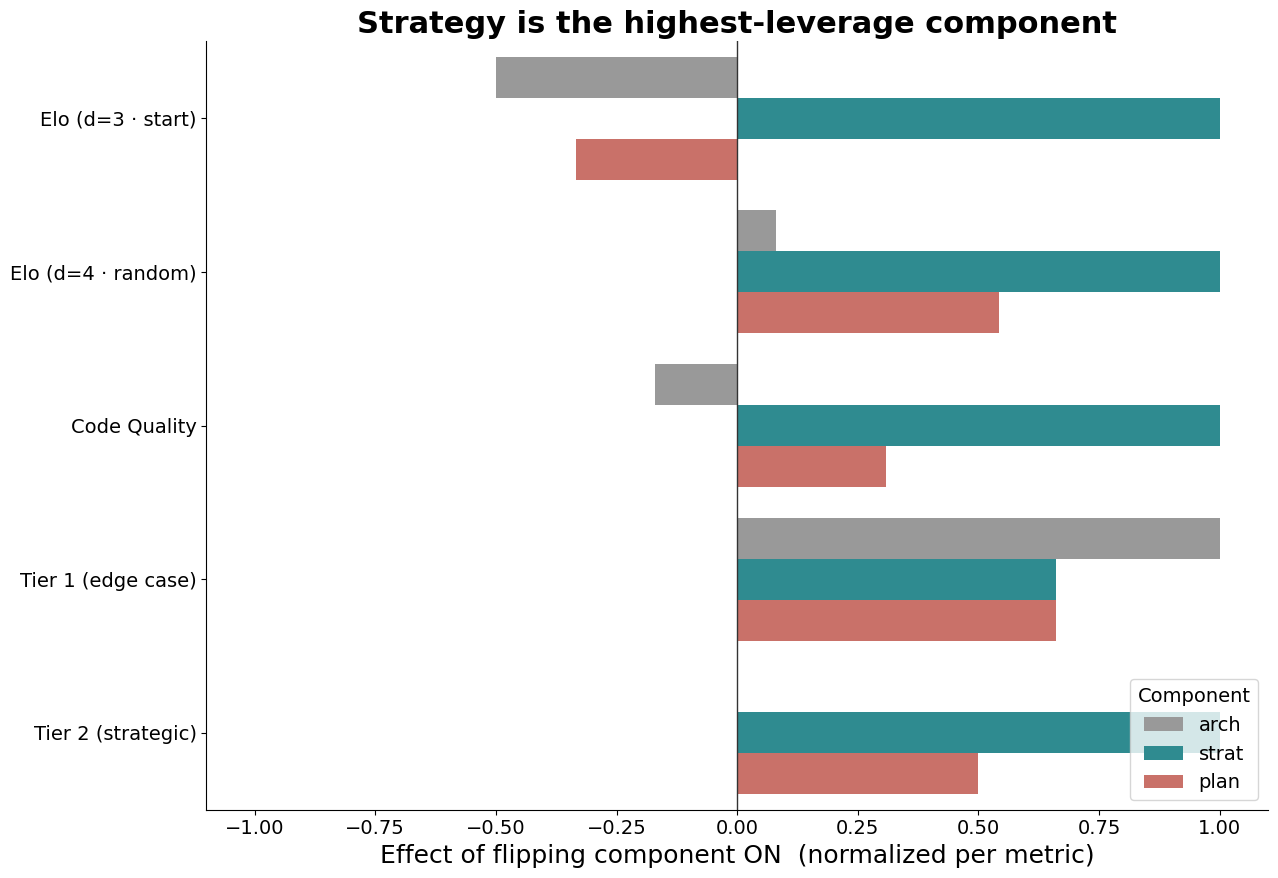

In [4]:
fig, ax = plt.subplots(figsize=(13, 9))

outcome_metrics = [
    ("elo_d3_zerostart", "Elo (d=3 · start)"),
    ("elo_d4_random",    "Elo (d=4 · random)"),
    ("code_quality",     "Code Quality"),
    ("tier1_pass_rate",  "Tier 1 (edge case)"),
    ("tier2_pass_rate",  "Tier 2 (strategic)"),
]

rows = []
for col, label in outcome_metrics:
    for flag, comp in [("has_arch", "arch"), ("has_strat", "strat"), ("has_plan", "plan")]:
        on  = master.loc[master[flag] == True,  col].mean()
        off = master.loc[master[flag] == False, col].mean()
        delta = on - off
        # Normalize per-row so each metric is comparable on one axis.
        rows.append({"metric": label, "component": comp, "delta": delta})
eff = pd.DataFrame(rows)

# Per-metric normalization so deltas of different scales (Elo vs 0-1 pass rate) coexist.
eff["delta_norm"] = eff.groupby("metric")["delta"].transform(
    lambda s: s / s.abs().max() if s.abs().max() > 0 else s
)

palette = {"arch": "#999999", "strat": "#1f9aa0", "plan": "#d96459"}
sns.barplot(
    data=eff, y="metric", x="delta_norm", hue="component",
    hue_order=["arch", "strat", "plan"],
    palette=palette, ax=ax,
)
ax.axvline(0, color="#333", lw=1)
ax.set_title("Strategy is the highest-leverage component")
ax.set_xlabel("Effect of flipping component ON  (normalized per metric)")
ax.set_ylabel("")
ax.set_xlim(-1.1, 1.1)
ax.legend(title="Component", loc="lower right")
plt.tight_layout()
plt.show()

## 3 · Persona is a second-order knob
> Among the three "all-on" runs (arch + strat + plan), we tested two personas:
> **p1 = C++ quant developer** and **p2 = caveman**. Below: how each persona
> moves the same outcome metrics *relative to the no-persona default* (run
> 1110, `arch1-strat1-plan1`).

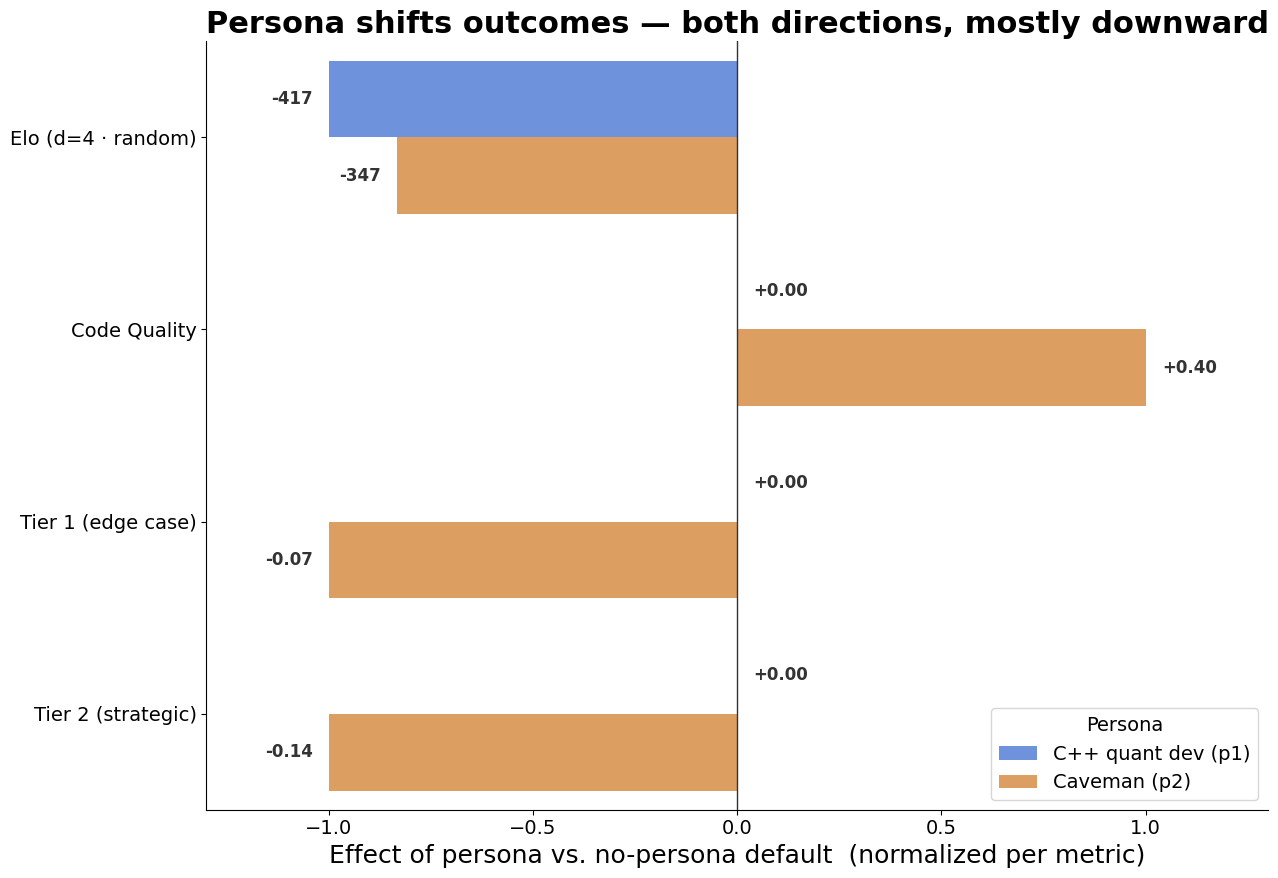

In [5]:
fig, ax = plt.subplots(figsize=(13, 9))

# Three "all-on" runs only.
default_eng = master[master["run_id"] == "1110"].iloc[0]   # no persona
quant_eng   = master[master["run_id"] == "1111"].iloc[0]   # C++ quant dev
caveman_eng = master[master["run_id"] == "1112"].iloc[0]   # caveman

persona_metrics = [
    ("elo_d3_zerostart", "Elo (d=3 · start)"),
    ("elo_d4_random",    "Elo (d=4 · random)"),
    ("code_quality",     "Code Quality"),
    ("tier1_pass_rate",  "Tier 1 (edge case)"),
    ("tier2_pass_rate",  "Tier 2 (strategic)"),
]

rows = []
for col, label in persona_metrics:
    base = default_eng[col]
    rows.append({"metric": label, "persona": "C++ quant dev (p1)", "delta": quant_eng[col]   - base})
    rows.append({"metric": label, "persona": "Caveman (p2)",       "delta": caveman_eng[col] - base})
delta_df = pd.DataFrame(rows)
# Drop rows where delta is NaN (e.g., d=3 zerostart Elo is missing for engines
# that swept or got swept and have no comparable Elo to subtract).
delta_df = delta_df.dropna(subset=["delta"]).reset_index(drop=True)
delta_df["delta_norm"] = delta_df.groupby("metric")["delta"].transform(
    lambda s: s / s.abs().max() if s.abs().max() > 0 else s
)

palette = {"C++ quant dev (p1)": "#5b8def", "Caveman (p2)": "#f29e4c"}
# Drop metrics where both personas are NaN (e.g., d=3 zerostart Elo: both
# personas swept or got swept, so no Elo was reported).
metric_order = [m[1] for m in persona_metrics if m[1] in delta_df["metric"].unique()]
persona_order = ["C++ quant dev (p1)", "Caveman (p2)"]

sns.barplot(
    data=delta_df, y="metric", x="delta_norm", hue="persona",
    order=metric_order, hue_order=persona_order,
    palette=palette, ax=ax,
)
ax.axvline(0, color="#333", lw=1)

# Annotate raw delta on each bar — compute positions from data, not patches.
hue_offsets = {persona_order[0]: -0.2, persona_order[1]: +0.2}
for _, row in delta_df.iterrows():
    raw = row["delta"]
    raw_str = f"{raw:+.0f}" if abs(raw) >= 1 else f"{raw:+.2f}"
    y = metric_order.index(row["metric"]) + hue_offsets[row["persona"]]
    x = row["delta_norm"]
    ax.text(x + (0.04 if x >= 0 else -0.04), y, raw_str,
            va="center", ha="left" if x >= 0 else "right",
            fontsize=12, fontweight="bold", color="#333")

ax.set_title("Persona shifts outcomes — both directions, mostly downward")
ax.set_xlabel("Effect of persona vs. no-persona default  (normalized per metric)")
ax.set_ylabel("")
ax.set_xlim(-1.3, 1.3)
ax.legend(title="Persona", loc="lower right")
plt.tight_layout()
plt.show()

## 4 · Contextual Friction
> **Insight:** With Planning enabled, more information acts as a catalyst.
> Without Planning, more information becomes drag — *contextual friction*.

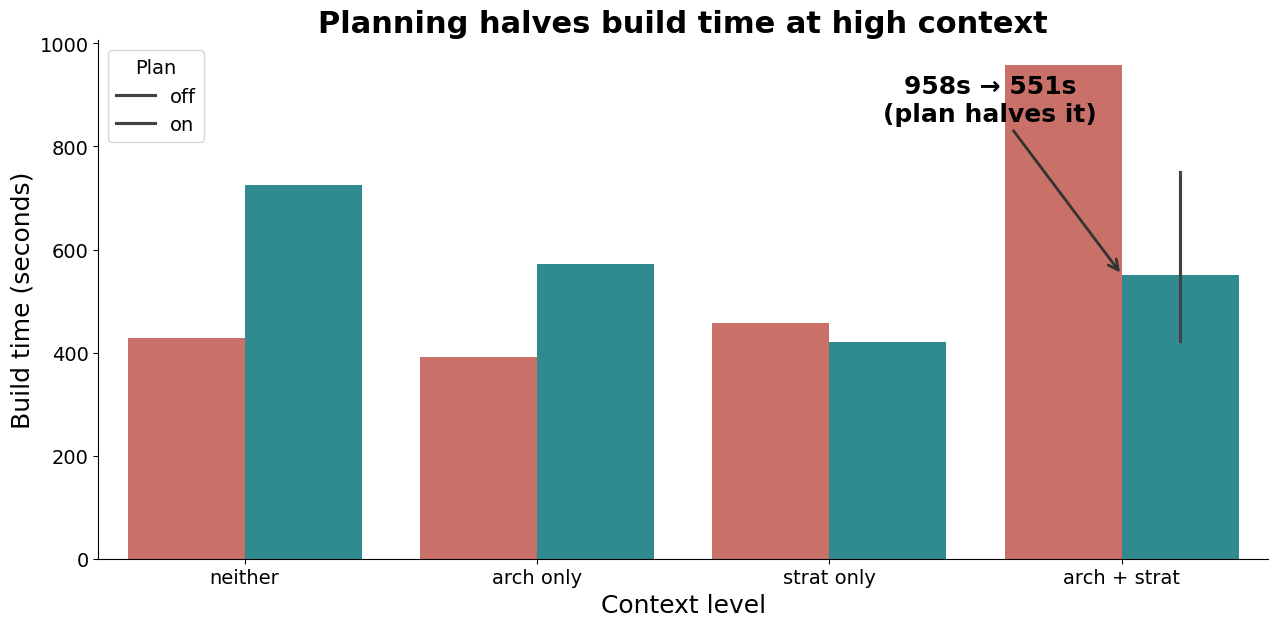

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ctx_labels = {0: "neither", 1: "arch only", 1.5: "strat only", 2: "arch + strat"}

# Treat strat-only and arch-only as separate buckets visually.
plot_df = build.copy()
plot_df["bucket"] = np.where(plot_df["context_level"] == 0, "neither",
                    np.where((plot_df["has_arch"]) & (~plot_df["has_strat"]), "arch only",
                    np.where((~plot_df["has_arch"]) & (plot_df["has_strat"]), "strat only",
                    "arch + strat")))
order = ["neither", "arch only", "strat only", "arch + strat"]

sns.barplot(
    data=plot_df, x="bucket", y="time_s", hue="has_plan",
    order=order, hue_order=[False, True],
    palette=[PLAN_PALETTE[False], PLAN_PALETTE[True]], ax=ax,
)

# Annotate the dramatic delta at arch+strat.
no_plan_at_full  = plot_df.query("bucket == 'arch + strat' and not has_plan")["time_s"].mean()
yes_plan_at_full = plot_df.query("bucket == 'arch + strat' and     has_plan")["time_s"].mean()
ax.annotate(
    f"{int(no_plan_at_full)}s → {int(yes_plan_at_full)}s\n(plan halves it)",
    xy=(3, yes_plan_at_full), xytext=(2.55, 850),
    fontsize=18, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", lw=2, color="#333"),
)

ax.set_title("Planning halves build time at high context")
ax.set_xlabel("Context level")
ax.set_ylabel("Build time (seconds)")
ax.legend(title="Plan", labels=["off", "on"], loc="upper left")
plt.tight_layout()
plt.show()

## 5 · The Token Hedge
> **Insight:** Planning has a fixed, predictable token cost regardless of complexity.
> Without it, tokens explode through *correction cycles*.

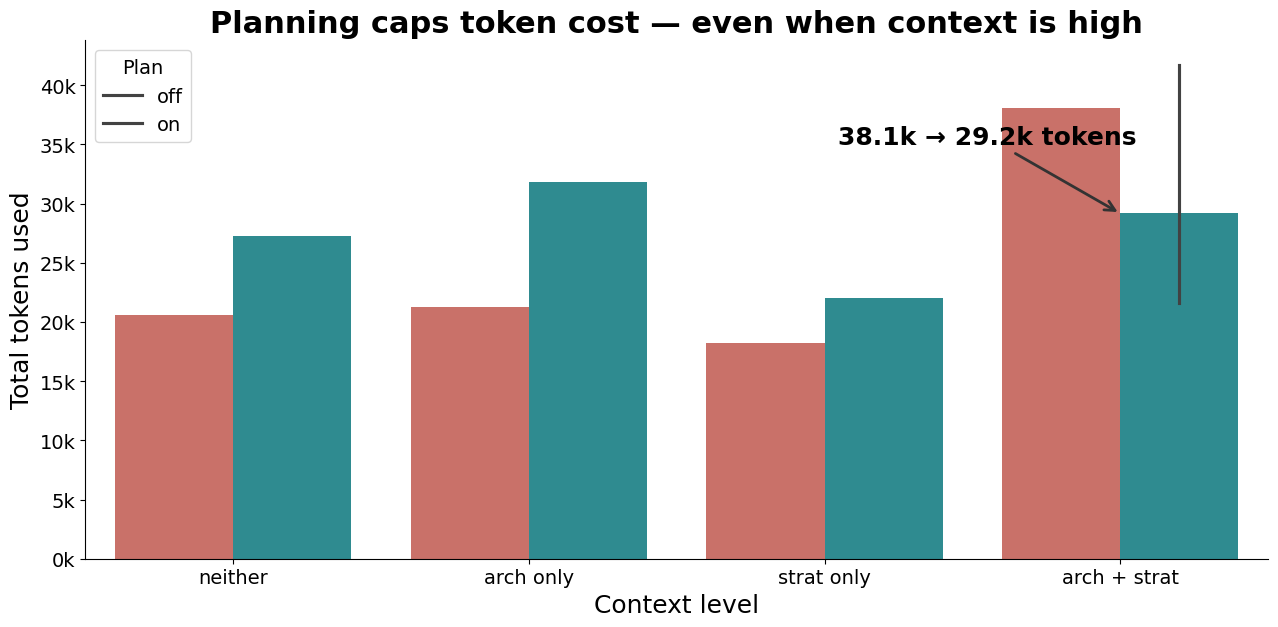

In [7]:
fig, ax = plt.subplots(figsize=(13, 6.5))
sns.barplot(
    data=plot_df, x="bucket", y="total_tokens", hue="has_plan",
    order=order, hue_order=[False, True],
    palette=[PLAN_PALETTE[False], PLAN_PALETTE[True]], ax=ax,
)

no_plan_full  = plot_df.query("bucket == 'arch + strat' and not has_plan")["total_tokens"].mean()
yes_plan_full = plot_df.query("bucket == 'arch + strat' and     has_plan")["total_tokens"].mean()
ax.annotate(
    f"{no_plan_full/1000:.1f}k → {yes_plan_full/1000:.1f}k tokens",
    xy=(3, yes_plan_full), xytext=(2.55, 35000),
    fontsize=18, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", lw=2, color="#333"),
)

ax.set_title("Planning caps token cost — even when context is high")
ax.set_xlabel("Context level")
ax.set_ylabel("Total tokens used")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.legend(title="Plan", labels=["off", "on"], loc="upper left")
plt.tight_layout()
plt.show()

## 6 · Quality across the Strategy split
> Of the three components, Strategy is the strongest mover for Code Quality
> (`+0.78 / 10` mean delta vs `+0.24` for Plan and `−0.13` for Architecture).
> Understanding shows the opposite — looser, more variable when Strategy is on.

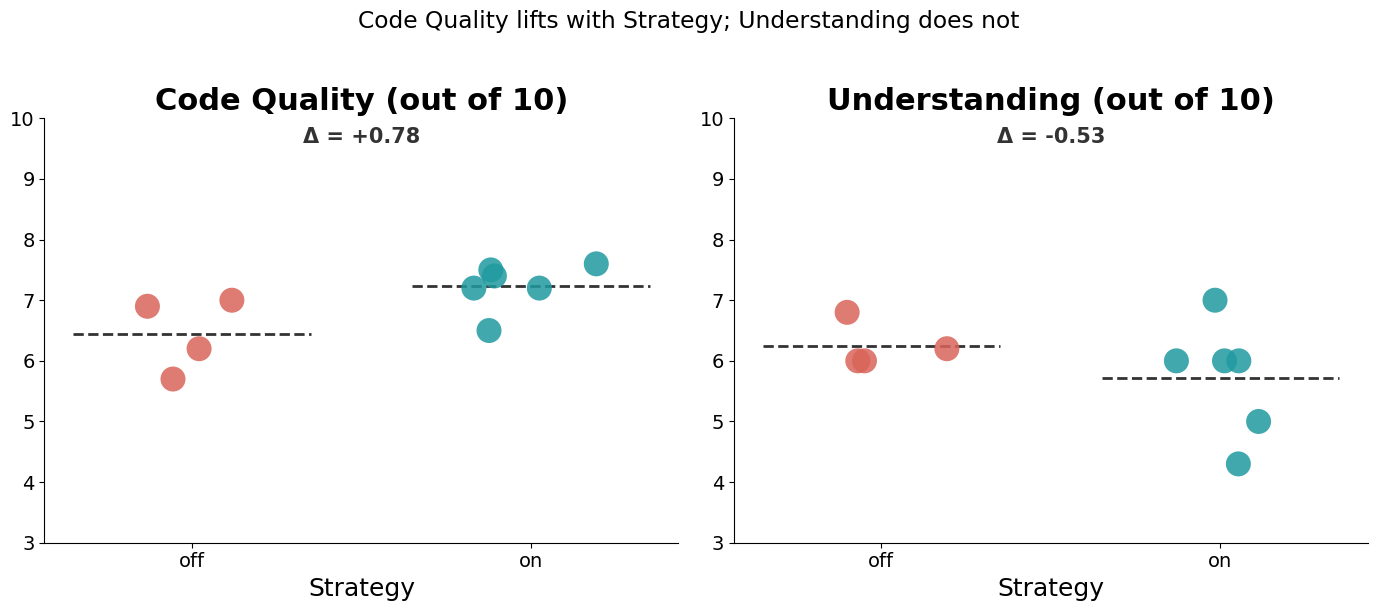

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in zip(
    axes, ["code_quality", "understanding"], ["Code Quality", "Understanding"]
):
    sns.stripplot(
        data=build, x="has_strat", y=col, hue="has_strat",
        order=[False, True], hue_order=[False, True],
        palette=[PLAN_PALETTE[False], PLAN_PALETTE[True]],
        size=18, jitter=0.2, alpha=0.85, legend=False, ax=ax,
    )
    mean_off = build.loc[~build["has_strat"], col].mean()
    mean_on  = build.loc[ build["has_strat"], col].mean()
    ax.hlines([mean_off, mean_on], xmin=[-0.35, 0.65], xmax=[0.35, 1.35],
              colors="#333", linewidth=2, linestyles="--")
    delta = mean_on - mean_off
    ax.text(0.5, 9.6, f"Δ = {delta:+.2f}", ha="center", fontsize=15,
            fontweight="bold", color="#333", transform=ax.transData)
    ax.set_title(f"{title} (out of 10)")
    ax.set_xlabel("Strategy")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["off", "on"])
    ax.set_ylabel("")
    ax.set_ylim(3, 10)

plt.suptitle("Code Quality lifts with Strategy; Understanding does not", y=1.02)
plt.tight_layout()
plt.show()

## 7 · Engines play — ordered by Strategy
> Engines are sorted left-to-right: **no-strat first, then yes-strat**.
> Note how the cluster on the right (yes-strat) sits *above zero* on average,
> while the no-strat cluster on the left sits *below*.

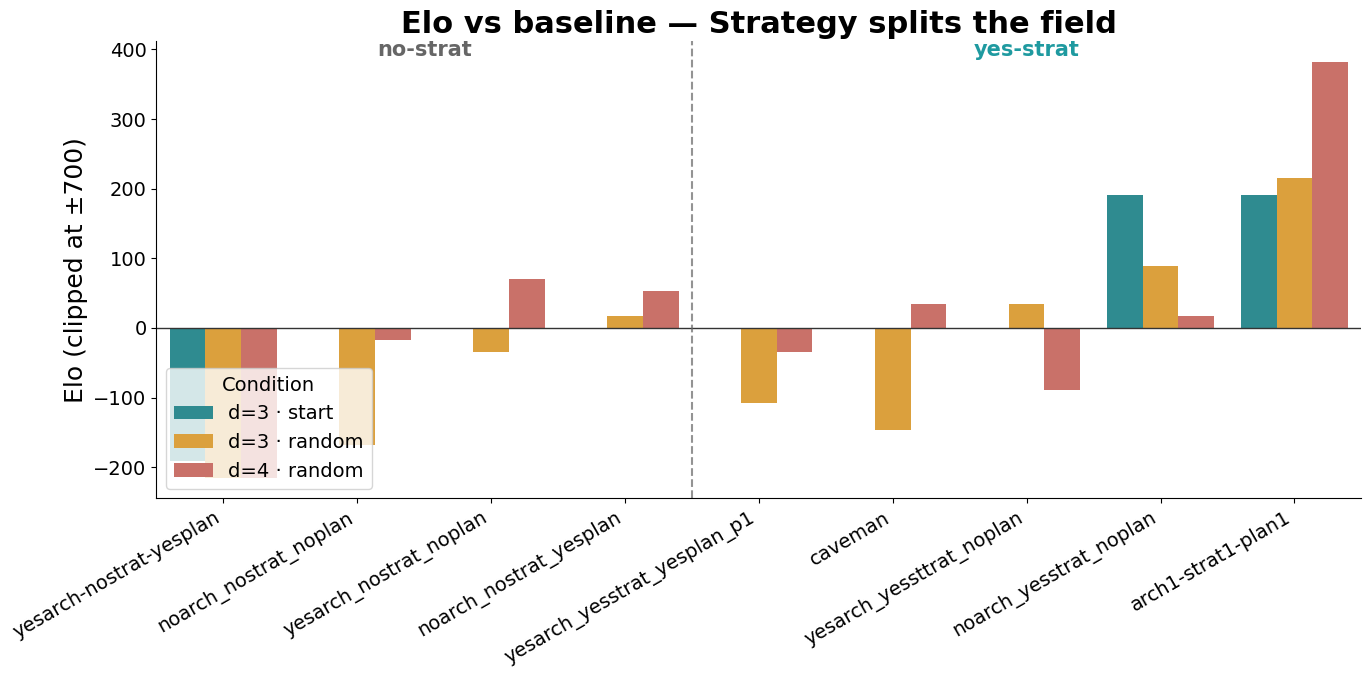

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
elo_long = master.melt(
    id_vars=["engine_name", "has_strat"],
    value_vars=["elo_d3_zerostart", "elo_d3_random", "elo_d4_random"],
    var_name="tournament", value_name="elo",
).dropna(subset=["elo"])

# Cap sentinel +/-2400 so the chart doesn't get crushed.
elo_long["elo_clipped"] = elo_long["elo"].clip(-700, 700)

label_map = {
    "elo_d3_zerostart": "d=3 · start",
    "elo_d3_random":    "d=3 · random",
    "elo_d4_random":    "d=4 · random",
}
elo_long["tournament"] = elo_long["tournament"].map(label_map)

# Order: nostrat first (sorted by mean Elo), then yesstrat (sorted by mean Elo).
mean_elo = elo_long.groupby(["engine_name", "has_strat"])["elo_clipped"].mean().reset_index()
no_strat = mean_elo[mean_elo["has_strat"] == False].sort_values("elo_clipped")["engine_name"].tolist()
yes_strat = mean_elo[mean_elo["has_strat"] == True].sort_values("elo_clipped")["engine_name"].tolist()
order_engines = no_strat + yes_strat

sns.barplot(
    data=elo_long, x="engine_name", y="elo_clipped", hue="tournament",
    order=order_engines, ax=ax,
    palette=["#1f9aa0", "#f5a623", "#d96459"],
)
ax.axhline(0, color="#333", lw=1)

# Vertical divider + group labels.
divider_x = len(no_strat) - 0.5
ax.axvline(divider_x, color="#666", lw=1.5, linestyle="--", alpha=0.7)
ymin, ymax = ax.get_ylim()
ax.text((len(no_strat)-1)/2, ymax * 0.95, "no-strat",
        ha="center", fontsize=15, fontweight="bold", color="#666")
ax.text(divider_x + (len(yes_strat))/2, ymax * 0.95, "yes-strat",
        ha="center", fontsize=15, fontweight="bold", color="#1f9aa0")

ax.set_title("Elo vs baseline — Strategy splits the field")
ax.set_xlabel("")
ax.set_ylabel("Elo (clipped at ±700)")
ax.tick_params(axis="x", rotation=30)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.legend(title="Condition", loc="lower left")
plt.tight_layout()
plt.show()

## 8 · Edge-Case Correctness & Strategic Decisions — split by Strategy
> Hand-authored fixtures probe whether the engine has *internalized* rules
> (Tier 1) and whether it makes *strategic* decisions consistent with
> Watkins-derived endgame theory (Tier 2).
> Engines on the **top** rows are yes-strat (teal); below the dashed line are no-strat (gray).
> Note the rightward shift on Tier 2 for the yes-strat cluster.

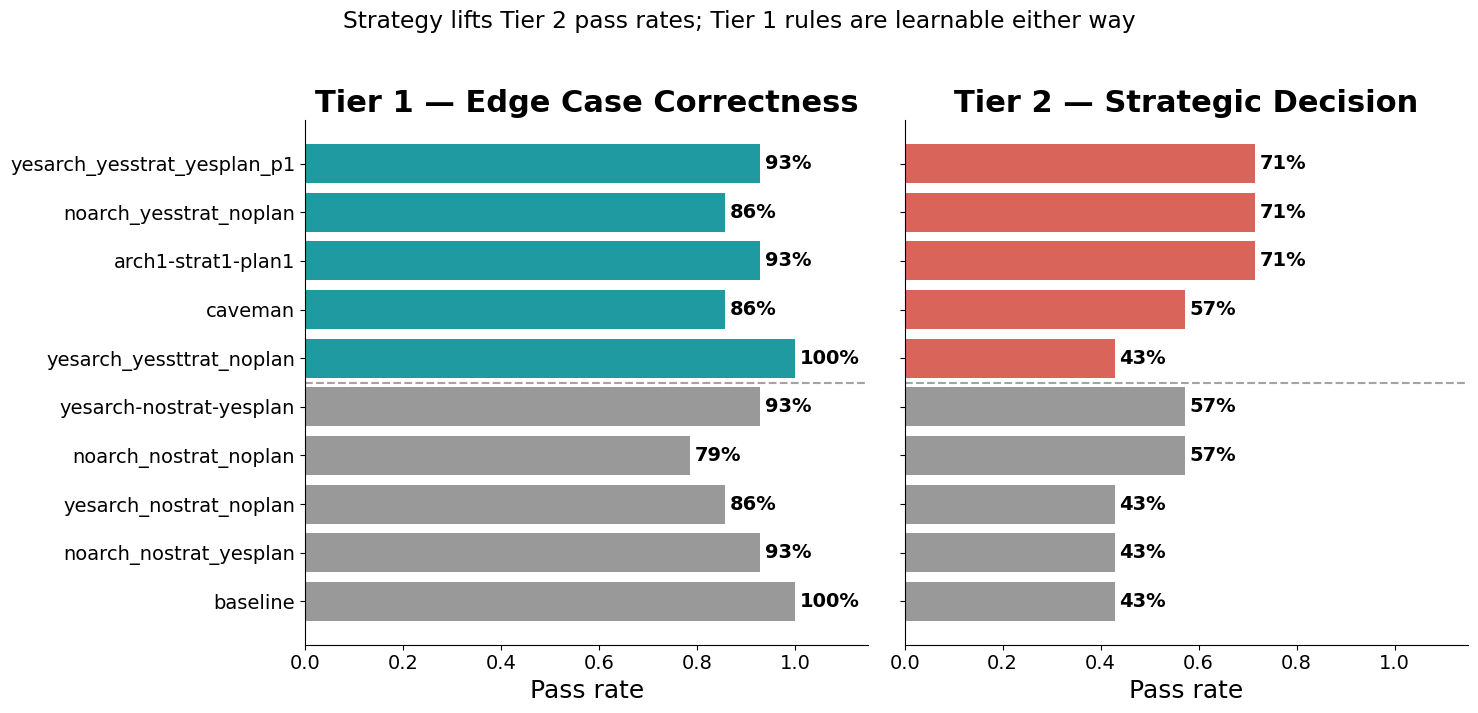

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Order: nostrat group first (top), yesstrat group second (bottom). Within each,
# sort by tier2 pass rate ascending. Join with `master` to know the strat flag.
strat_lookup = master.set_index("engine_name")["has_strat"].to_dict()
corr = correctness.copy()
corr["has_strat"] = corr["engine_name"].map(strat_lookup).fillna(False).astype(bool)
corr = pd.concat([
    corr[corr["has_strat"] == False].sort_values("tier2_pass_rate"),
    corr[corr["has_strat"] == True ].sort_values("tier2_pass_rate"),
], ignore_index=True)

bar_colors_t1 = ["#999999" if not s else "#1f9aa0" for s in corr["has_strat"]]
bar_colors_t2 = ["#999999" if not s else "#d96459" for s in corr["has_strat"]]

axes[0].barh(corr["engine_name"], corr["tier1_pass_rate"], color=bar_colors_t1)
for i, v in enumerate(corr["tier1_pass_rate"]):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va="center",
                 fontsize=14, fontweight="bold")
axes[0].set_xlim(0, 1.15)
axes[0].set_title("Tier 1 — Edge Case Correctness")
axes[0].set_xlabel("Pass rate")

axes[1].barh(corr["engine_name"], corr["tier2_pass_rate"], color=bar_colors_t2)
for i, v in enumerate(corr["tier2_pass_rate"]):
    axes[1].text(v + 0.01, i, f"{v:.0%}", va="center",
                 fontsize=14, fontweight="bold")
axes[1].set_xlim(0, 1.15)
axes[1].set_title("Tier 2 — Strategic Decision")
axes[1].set_xlabel("Pass rate")

# Group separator line between nostrat and yesstrat.
n_no = (~corr["has_strat"]).sum()
for ax in axes:
    ax.axhline(n_no - 0.5, color="#666", lw=1.5, linestyle="--", alpha=0.6)

plt.suptitle("Strategy lifts Tier 2 pass rates; Tier 1 rules are learnable either way", y=1.02)
plt.tight_layout()
plt.show()

## 9 · The Full Picture
> Rows sorted: **nostrat first, then yesstrat**.
> Within each group, sorted by `arch` then `plan`.
> Look down the Elo and Tier 2 columns — the bottom half is greener.

In [11]:
def fmt_money(v):
    return "" if pd.isna(v) else f"${v:.2f}"

def fmt_int(v):
    return "" if pd.isna(v) else f"{int(v):,}"

def fmt_elo(v):
    return "" if pd.isna(v) else f"{v:+.0f}"

display_cols = [
    "run_id", "engine_name", "time_s", "total_tokens", "cost_usd",
    "code_quality", "understanding",
    "elo_d3_zerostart", "elo_d3_random", "elo_d4_random",
    "tier1_pass_rate", "tier2_pass_rate",
]
sort_cols = ["has_strat", "has_arch", "has_plan", "plan_variant"]
tbl = (master.sort_values(sort_cols)[display_cols]
       .reset_index(drop=True))

styled = (
    tbl.style
    .format({
        "time_s":           lambda v: f"{int(v)}s",
        "total_tokens":     fmt_int,
        "cost_usd":         fmt_money,
        "code_quality":     "{:.1f}",
        "understanding":    "{:.1f}",
        "elo_d3_zerostart": fmt_elo,
        "elo_d3_random":    fmt_elo,
        "elo_d4_random":    fmt_elo,
        "tier1_pass_rate":  "{:.0%}",
        "tier2_pass_rate":  "{:.0%}",
    }, na_rep="—")
    .background_gradient(subset=["cost_usd"],         cmap="Reds")
    .background_gradient(subset=["elo_d4_random"],    cmap="RdYlGn")
    .background_gradient(subset=["tier2_pass_rate"],  cmap="Blues")
    .set_properties(**{"font-size": "13pt", "text-align": "right"})
    .set_caption("Master summary — every run, every metric")
)
styled

,run_id,engine_name,time_s,total_tokens,cost_usd,code_quality,understanding,elo_d3_zerostart,elo_d3_random,elo_d4_random,tier1_pass_rate,tier2_pass_rate
0,0000,noarch_nostrat_noplan,428s,"20,590",$0.90,6.2,6.0,—,-168,-17,79%,57%
1,0010,noarch_nostrat_yesplan,726s,"27,300",$1.08,6.9,6.0,-0,+17,+52,93%,43%
2,1000,yesarch_nostrat_noplan,391s,"21,300",$1.19,7.0,6.8,-0,-35,+70,86%,43%
3,1010,yesarch-nostrat-yesplan,571s,"31,800",$0.99,5.7,6.2,-191,-215,-215,93%,57%
4,0100,noarch_yesstrat_noplan,457s,"18,200",$0.57,7.4,6.0,+191,+89,+17,86%,71%
5,0110,—,420s,"22,000",$0.19,7.5,6.0,—,—,—,—,—
6,1100,yesarch_yessttrat_noplan,958s,"38,100",$1.19,6.5,6.0,-0,+35,-89,100%,43%
7,1110,arch1-strat1-plan1,479s,"21,600",$0.67,7.2,7.0,+191,+215,+382,93%,71%
8,1111,yesarch_yesstrat_yesplan_p1,751s,"41,700",$1.02,7.2,5.0,—,-108,-35,93%,71%
9,1112,caveman,423s,"24,200",$0.72,7.6,4.3,—,-147,+35,86%,57%
